# 07 · Score de Saúde por Produto

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autor(es):** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Data de criação:** 05/08/2026
**Última atualização:** 05/08/2026

## Objetivo

Atribuir a cada produto uma nota de 0 a 100 que sintetize sua condição operacional, com ranking,
tendência e decomposição da nota em seus componentes. É o segundo diferencial declarado nas Sprints 1
e 2.

A primeira questão a resolver não é como calcular a nota, e sim se ela acrescenta informação ao
`04_risco_ola.ipynb`. Uma nota que reproduza a média do risco por produto seria o modelo anterior
reagrupado. A seção 3 responde essa questão antes de qualquer construção.

## Dependências

- Python 3.11+
- pandas, numpy, matplotlib

## Entradas

- `data/interim/incidentes_kpi.parquet` (gerado pelo `02_base_kpi.ipynb`)

## Saídas

- Gráficos exportados para `notebooks/figures/07_saude_produto/`
- Tabela em `data/interim/07_saude_produto.parquet`, para consumo pela aplicação
- Resultados documentados em `docs/sprint-3-mvp.md`

## Sumário

| Seção | Conteúdo |
|---|---|
| 3 | o score se sobrepõe ao modelo de risco? |
| 4.1 | os componentes candidatos |
| 4.2 | teste de redundância entre componentes |
| 4.3 | construção da nota |
| 4.4 | o ranking e a decomposição |
| 4.5 | risco latente: produto com problema novo que ainda não estourou |
| 4.6 | sensibilidade da nota aos pesos |
| 4.7 | saída para a aplicação |
| 5 | conclusões e limitações |

In [1]:
# Stdlib
import re
import warnings
from pathlib import Path

# Third-party
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

## 1. Setup

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'
FIG_DIR = RAIZ / 'notebooks' / 'figures' / '07_saude_produto'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MINIMO_INCIDENTES = 200      # volume mínimo para o produto entrar no ranking

def fmt(x, casas=2):
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

Além da base, são derivadas três marcações usadas como componentes: se o problema do incidente é
inédito, se a causa foi identificada no fechamento, e o tempo de resolução em horas.

A marcação de problema inédito reutiliza a normalização de texto definida no
`05_causas_recorrentes.ipynb`, seção 4.4.

In [3]:
df_kpi = pd.read_parquet(PARQUET)
df_kpi['violou'] = (df_kpi['KPI Violado?'] == 'SIM').astype(int)

def normaliza(texto):
    """Mesma normalização do 05: substitui identificador de ativo e números por marcadores."""
    s = re.sub(r'IC\d{4,}', '<ativo>', str(texto))
    s = re.sub(r'\d+', '<n>', s)
    return re.sub(r'\s+', ' ', s).strip().lower()

df_kpi['problema'] = df_kpi['Descrição resumida'].map(normaliza)
df_kpi['vezes'] = df_kpi['problema'].map(df_kpi['problema'].value_counts())
df_kpi['inedito'] = (df_kpi['vezes'] == 1).astype(int)
df_kpi['sem_causa'] = df_kpi['Código de fechamento'].isin(['Outro', 'Falha não reproduzida']).astype(int)
df_kpi['horas'] = df_kpi['Duração'] / 3600          # o campo vem em segundos

df_ano = df_kpi[df_kpi['ano'] == 2025].copy()
TAXA_BASE = df_ano['violou'].mean()

print(f'2025: {fmt_int(len(df_ano))} incidentes, {int(df_ano["violou"].sum())} violações de OLA')
print(f'taxa de violação em 2025: {fmt(TAXA_BASE * 100)}%  '
      f'(na base inteira, incluindo 2023 e 2024, é de {fmt(df_kpi["violou"].mean()*100)}%)')
print(f'produtos distintos: {df_ano["Produto"].astype(str).nunique()}')

2025: 25.156 incidentes, 238 violações de OLA
taxa de violação em 2025: 0,95%  (na base inteira, incluindo 2023 e 2024, é de 0,97%)
produtos distintos: 46


## 3. O score se sobrepõe ao modelo de risco?

O `04_risco_ola.ipynb` atribui probabilidade de violação a cada incidente. A média dessas
probabilidades por produto é uma nota de produto, e se ela contivesse a mesma informação que os
demais candidatos, este notebook seria redundante.

A verificação compara a taxa de violação observada por produto, que é a grandeza que o modelo de risco
estima, com os outros candidatos a componente. Se a correlação for alta, o candidato não acrescenta.

In [4]:
def agrega_produtos(dados):
    g = dados.groupby(dados['Produto'].astype(str)).agg(
        incidentes=('violou', 'size'),
        violacoes=('violou', 'sum'),
        taxa_violacao=('violou', 'mean'),
        prop_inedito=('inedito', 'mean'),
        prop_sem_causa=('sem_causa', 'mean'),
        duracao_mediana_h=('horas', 'median'),
        ativos=('Item de configuração', 'nunique'))
    g['incidentes_por_ativo'] = g['incidentes'] / g['ativos']
    return g[g['incidentes'] >= MINIMO_INCIDENTES]

prod = agrega_produtos(df_ano)

# tendencia: variacao da taxa de violacao do segundo semestre contra o primeiro
tx1 = df_ano[df_ano['mes'] <= 6].groupby(df_ano['Produto'].astype(str))['violou'].mean()
tx2 = df_ano[df_ano['mes'] > 6].groupby(df_ano['Produto'].astype(str))['violou'].mean()
prod['tendencia'] = (tx2 - tx1).reindex(prod.index)

COMPONENTES = ['taxa_violacao', 'prop_inedito', 'prop_sem_causa',
               'duracao_mediana_h', 'incidentes_por_ativo', 'tendencia']
print(f'{len(prod)} produtos com pelo menos {MINIMO_INCIDENTES} incidentes em 2025')
print(f'eles cobrem {prod["incidentes"].sum()/len(df_ano)*100:.0f}% do volume e '
      f'{int(prod["violacoes"].sum())} das {int(df_ano["violou"].sum())} violações')
print()
print('correlação entre a taxa de violação e os demais candidatos:')
correl = prod[COMPONENTES].corr()['taxa_violacao'].drop('taxa_violacao').round(2)
print(correl.to_string())

17 produtos com pelo menos 200 incidentes em 2025
eles cobrem 95% do volume e 219 das 238 violações

correlação entre a taxa de violação e os demais candidatos:
prop_inedito            0.11
prop_sem_causa          0.53
duracao_mediana_h      -0.41
incidentes_por_ativo   -0.24
tendencia              -0.02


**Achado:** a correlação entre a taxa de violação e a proporção de casos inéditos é de 0,11, o que
caracteriza grandezas praticamente independentes. As demais ficam entre 0,53 e −0,41.

Um produto pode apresentar taxa de violação baixa e, ao mesmo tempo, concentração alta de problemas
inéditos. Como o `05_causas_recorrentes.ipynb` estabeleceu que o problema inédito viola o OLA 4,6 vezes
mais que o problema de rotina, essa combinação corresponde a risco ainda não materializado, e é
invisível ao modelo de risco: ele avalia incidentes isolados, e cada incidente desse produto apresenta
probabilidade individual baixa.

Há uma segunda razão para o score não ser redundante. O modelo de risco só pode usar informação
disponível na abertura do incidente, o que exclui código de fechamento e duração. O score não tem essa
restrição, porque descreve o passado em vez de prever. Os dois artefatos são complementares
precisamente por causa da restrição de vazamento que separa suas fontes de informação.

## 4. Construção

### 4.1 Os componentes

Seis candidatos, todos com direção definida: valor mais alto significa condição pior.

| Componente | O que mede | Fonte |
|---|---|---|
| `taxa_violacao` | proporção de incidentes que violaram o OLA | campo oficial |
| `prop_inedito` | proporção de problemas que aparecem uma única vez | notebook 05 |
| `prop_sem_causa` | proporção fechada como "Outro" ou "Falha não reproduzida" | notebook 05 |
| `duracao_mediana_h` | tempo mediano de resolução | campo `Duração` |
| `incidentes_por_ativo` | quantos incidentes por item de configuração | derivado |
| `tendencia` | variação da taxa entre semestres | derivado |

### 4.2 Teste de redundância entre componentes

Antes de compor a nota, é necessário verificar se algum par mede a mesma coisa. Componentes redundantes
dariam peso dobrado ao mesmo fenômeno.

In [5]:
matriz = prod[COMPONENTES].corr().round(2)
print(matriz.to_string())
print()
LIMITE_REDUNDANCIA = 0.80
pares = [(a, b, matriz.loc[a, b]) for i, a in enumerate(COMPONENTES)
         for b in COMPONENTES[i+1:] if abs(matriz.loc[a, b]) >= LIMITE_REDUNDANCIA]
if pares:
    print(f'pares com correlação de módulo acima de {LIMITE_REDUNDANCIA}:')
    for a, b, v in pares:
        print(f'  {a} e {b}: {v}')
else:
    print(f'nenhum par acima de {LIMITE_REDUNDANCIA}')

                      taxa_violacao  prop_inedito  prop_sem_causa  duracao_mediana_h  incidentes_por_ativo  tendencia
taxa_violacao                  1.00          0.11            0.53              -0.41                 -0.24      -0.02
prop_inedito                   0.11          1.00            0.24               0.24                  0.13       0.53
prop_sem_causa                 0.53          0.24            1.00              -0.36                 -0.54       0.49
duracao_mediana_h             -0.41          0.24           -0.36               1.00                  0.85       0.01
incidentes_por_ativo          -0.24          0.13           -0.54               0.85                  1.00      -0.17
tendencia                     -0.02          0.53            0.49               0.01                 -0.17       1.00

pares com correlação de módulo acima de 0.8:
  duracao_mediana_h e incidentes_por_ativo: 0.85


**Achado:** `duracao_mediana_h` e `incidentes_por_ativo` apresentam correlação de 0,85, acima do
limite adotado. Manter os dois atribuiria peso duplo ao mesmo fenômeno.

`duracao_mediana_h` é mantida e `incidentes_por_ativo` é descartada. O critério é interpretabilidade:
tempo de resolução tem leitura operacional direta, enquanto incidentes por ativo depende do inventário
cadastrado, que varia por produto por razões alheias à condição operacional.

Os cinco componentes restantes têm correlação máxima de 0,53 entre si.

### 4.3 Construção da nota

Cada componente é convertido em posição relativa dentro do conjunto de produtos avaliados, e a nota é a
média dessas posições, invertida para que 100 corresponda à melhor condição.

**Duas escolhas explícitas.**

A primeira é usar **posição relativa** em vez do valor absoluto. A consequência é que a nota compara
produtos entre si e não contra um padrão externo: o produto de melhor nota é o melhor do conjunto, não
um produto sem problemas. A alternativa exigiria um valor de referência por componente, que não existe
no material oficial.

A segunda é **peso igual** para os cinco componentes. Não há base no dado para afirmar que um deles
importe mais para a condição do produto, e atribuir pesos diferentes sem esse lastro seria arbitrário.
A seção 4.6 mede o quanto o ranking depende dessa escolha.

In [6]:
USADOS = ['taxa_violacao', 'prop_inedito', 'prop_sem_causa', 'duracao_mediana_h', 'tendencia']

def calcula_nota(tabela, componentes, pesos=None):
    """Nota de 0 a 100: média das posições relativas invertidas. 100 é a melhor condição."""
    if pesos is None:
        pesos = {c: 1.0 for c in componentes}
    total = sum(pesos[c] for c in componentes)
    # posicao relativa: 0 para o melhor valor do conjunto, 1 para o pior
    posicoes = pd.DataFrame({c: tabela[c].rank(pct=True) for c in componentes}, index=tabela.index)
    ruim = sum(posicoes[c] * pesos[c] for c in componentes) / total
    return (100 * (1 - ruim)).round(1), posicoes

prod['nota'], POSICOES = calcula_nota(prod, USADOS)
prod['posicao'] = prod['nota'].rank(ascending=False, method='min').astype(int)

ranking = prod.sort_values('nota').copy()
vista = ranking[['posicao', 'nota', 'incidentes', 'violacoes']].copy()
vista['taxa %'] = (ranking['taxa_violacao'] * 100).round(2)
vista['inéditos %'] = (ranking['prop_inedito'] * 100).round(1)
vista['sem causa %'] = (ranking['prop_sem_causa'] * 100).round(1)
vista['duração h'] = ranking['duracao_mediana_h'].round(2)
vista['tendência pp'] = (ranking['tendencia'] * 100).round(2)
print('ranking do pior para o melhor:')
print(vista.to_string())

ranking do pior para o melhor:
         posicao  nota  incidentes  violacoes  taxa %  inéditos %  sem causa %  duração h  tendência pp
Produto                                                                                                
lssl          17  15.3         454          9    1.98        64.1         13.0       3.69          0.55
lrdo          16  20.0         482          8    1.66        63.9         17.2       1.28          0.98
lvps          15  21.2         418         10    2.39        46.9         29.2       1.15          0.93
lsaa          14  23.5         554          8    1.44        30.7         21.5       1.65          1.05
lemg          13  34.1         388          4    1.03        62.6          8.2       4.48          0.23
lcsp          12  35.3         272          2    0.74        54.8         23.5       1.26          0.53
lsin          11  41.2        3190         62    1.94        28.2         20.4       1.35         -1.11
lrel          10  45.9         49

### 4.4 A decomposição da nota

Uma nota sem decomposição não é acionável. Para cada produto, o componente de pior posição relativa
indica onde a condição se deteriora.

In [7]:
def explica_nota(produto):
    p = POSICOES.loc[produto].sort_values(ascending=False)
    nota = prod.loc[produto, 'nota']
    linhas = [f'{produto} · nota {fmt(nota, 1)} · posição {int(prod.loc[produto, "posicao"])} '
              f'de {len(prod)}']
    for comp, pos in p.items():
        valor = prod.loc[produto, comp]
        bruto = (f'{fmt(valor*100, 1)}%' if comp in ('taxa_violacao', 'prop_inedito', 'prop_sem_causa')
                 else (f'{fmt(valor*100, 2)} pp' if comp == 'tendencia' else f'{fmt(valor, 2)} h'))
        marca = 'pior' if pos >= 0.8 else ('melhor' if pos <= 0.2 else '')
        linhas.append(f'   {comp:22s} {bruto:>10s}   posição relativa {fmt(pos, 2)}  {marca}')
    return '\n'.join(linhas)

for produto in ranking.index[:3]:
    print(explica_nota(produto))
    print()

lssl · nota 15,3 · posição 17 de 17
   prop_inedito                64,1%   posição relativa 1,00  pior
   taxa_violacao                2,0%   posição relativa 0,94  pior
   duracao_mediana_h          3,69 h   posição relativa 0,82  pior
   tendencia                 0,55 pp   posição relativa 0,76  
   prop_sem_causa              13,0%   posição relativa 0,71  

lrdo · nota 20,0 · posição 16 de 17
   prop_inedito                63,9%   posição relativa 0,94  pior
   tendencia                 0,98 pp   posição relativa 0,94  pior
   taxa_violacao                1,7%   posição relativa 0,76  
   prop_sem_causa              17,2%   posição relativa 0,76  
   duracao_mediana_h          1,28 h   posição relativa 0,59  

lvps · nota 21,2 · posição 15 de 17
   taxa_violacao                2,4%   posição relativa 1,00  pior
   prop_sem_causa              29,2%   posição relativa 1,00  pior
   tendencia                 0,93 pp   posição relativa 0,88  pior
   prop_inedito                46,9%   

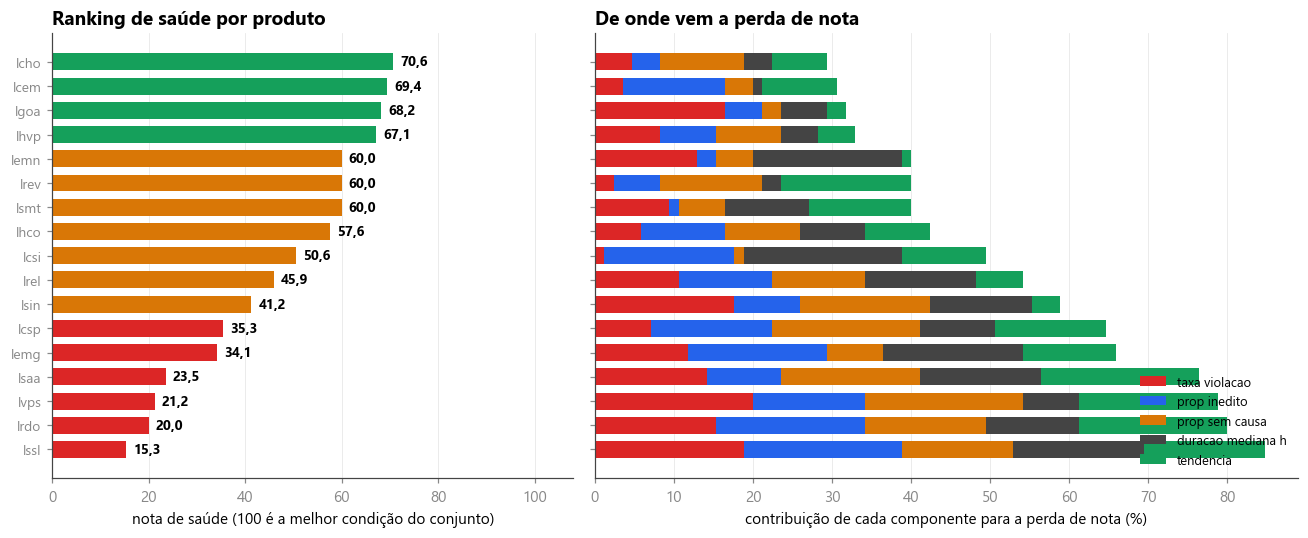

In [8]:
# figura 01: o ranking com a nota decomposta
r = ranking.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 5.0), gridspec_kw={'width_ratios': [1, 1.35]})

cores = [COR['danger'] if n < 40 else (COR['ambar'] if n < 65 else COR['verde']) for n in r['nota']]
ax1.barh(range(len(r)), r['nota'], color=cores, height=0.7)
for i, n in enumerate(r['nota']):
    ax1.text(n + 1.5, i, fmt(n, 1), va='center', fontsize=9, fontweight='bold')
ax1.set_yticks(range(len(r))); ax1.set_yticklabels(r.index, fontsize=9)
ax1.set_xlim(0, 108); ax1.set_xlabel('nota de saúde (100 é a melhor condição do conjunto)')
ax1.set_title('Ranking de saúde por produto', loc='left')
ax1.grid(axis='y', visible=False); ax1.grid(axis='x', visible=True)

paleta = {'taxa_violacao': COR['danger'], 'prop_inedito': COR['accent'],
          'prop_sem_causa': COR['ambar'], 'duracao_mediana_h': COR['cinza_esc'],
          'tendencia': COR['verde']}
pos_r = POSICOES.loc[r.index]
esquerda = np.zeros(len(r))
for comp in USADOS:
    v = pos_r[comp].values / len(USADOS) * 100
    ax2.barh(range(len(r)), v, left=esquerda, color=paleta[comp], height=0.7,
             label=comp.replace('_', ' '))
    esquerda += v
ax2.set_yticks(range(len(r))); ax2.set_yticklabels([], fontsize=9)
ax2.set_xlabel('contribuição de cada componente para a perda de nota (%)')
ax2.set_title('De onde vem a perda de nota', loc='left')
ax2.grid(axis='y', visible=False); ax2.grid(axis='x', visible=True)
ax2.legend(loc='lower right', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '01_ranking_saude'); plt.show()

In [9]:
# o produto lcsi apresenta duracao mediana muito acima das demais; vale isolar a causa
extremo = prod['duracao_mediana_h'].idxmax()
sub = df_ano[df_ano['Produto'].astype(str) == extremo]
print(f'{extremo}: duração mediana de {fmt(prod.loc[extremo, "duracao_mediana_h"], 1)} h '
      f'({fmt(prod.loc[extremo, "duracao_mediana_h"]/24, 1)} dias)')
print(f'   taxa de violação: {fmt(prod.loc[extremo, "taxa_violacao"]*100, 2)}% '
      f'(a menor do conjunto)')
print()
print('   composição por status:')
print('   ' + sub['Status'].astype(str).value_counts(normalize=True).head(3)
      .mul(100).round(1).to_string().replace(chr(10), chr(10) + '   '))
print()
comparacao = df_ano.groupby(df_ano['Status'].astype(str)).agg(
    incidentes=('violou', 'size'), taxa=('violou', 'mean'), dur_h=('horas', 'median'))
comparacao = comparacao[comparacao['incidentes'] >= 200]
comparacao['taxa %'] = (comparacao['taxa'] * 100).round(2)
comparacao['duração mediana h'] = comparacao['dur_h'].round(1)
print('   por status, na base inteira de 2025:')
print('   ' + comparacao[['incidentes', 'taxa %', 'duração mediana h']].to_string()
      .replace(chr(10), chr(10) + '   '))

lcsi: duração mediana de 335,3 h (14,0 dias)
   taxa de violação: 0,09% (a menor do conjunto)

   composição por status:
   Status
   Encerrado Automaticamente    86.0
   Encerrado                    14.0

   por status, na base inteira de 2025:
                              incidentes  taxa %  duração mediana h
   Status                                                          
   Encerrado                       10423    0.98                0.8
   Encerrado Automaticamente       14733    0.92                1.7


**Achado, e ele conecta com a seção 4.2.1 do `04_risco_ola.ipynb`.** O produto `lcsi` apresenta
duração mediana de 335 horas, cerca de catorze dias, ao lado da menor taxa de violação do conjunto.
A combinação é a mesma anomalia já documentada: incidentes com status `Encerrado Automaticamente`
acumulam duração longa e não registram violação, o que indica que a apuração oficial do OLA os exclui.

Consequência para a nota: o componente de duração penaliza `lcsi` por um tempo que reflete encerramento
por inatividade, não atendimento lento. A nota resultante o coloca em posição intermediária, portanto o
efeito não domina o resultado, mas a leitura do componente de duração desse produto não deve ser feita
como tempo de trabalho.

A alternativa seria excluir os incidentes de encerramento automático do cálculo de duração. Ela não foi
adotada porque exigiria decidir se esses incidentes representam ou não trabalho da operação, e o dataset
não traz elemento para essa distinção. Fica declarado como limitação.

### 4.5 Risco latente

O caso que justifica a existência do score: produtos com concentração alta de problemas inéditos e taxa
de violação ainda baixa. A combinação indica exposição que não se materializou no período medido.

In [10]:
mediana_ined = prod['prop_inedito'].median()
mediana_taxa = prod['taxa_violacao'].median()

def quadrante(linha):
    alto_ined = linha['prop_inedito'] > mediana_ined
    alta_taxa = linha['taxa_violacao'] > mediana_taxa
    if alto_ined and alta_taxa:
        return 'problema já materializado'
    if alto_ined and not alta_taxa:
        return 'risco latente'
    if not alto_ined and alta_taxa:
        return 'problema conhecido e recorrente'
    return 'estável'

prod['quadrante'] = prod.apply(quadrante, axis=1)
print(f'mediana de casos inéditos: {fmt(mediana_ined*100, 1)}% | '
      f'mediana da taxa de violação: {fmt(mediana_taxa*100, 2)}%')
print()
resumo = prod.groupby('quadrante').agg(produtos=('nota', 'size'), nota_media=('nota', 'mean')).round(1)
print(resumo.to_string())
print()
for q in ['risco latente', 'problema já materializado']:
    s = prod[prod['quadrante'] == q].sort_values('prop_inedito', ascending=False)
    if len(s):
        print(f'{q}:')
        for i in s.index:
            print(f'   {i}: {fmt(s.loc[i, "prop_inedito"]*100, 1)}% inéditos, '
                  f'taxa de {fmt(s.loc[i, "taxa_violacao"]*100, 2)}%, nota {fmt(s.loc[i, "nota"], 1)}')
        print()

mediana de casos inéditos: 35,2% | mediana da taxa de violação: 1,00%

                                 produtos  nota_media
quadrante                                            
estável                                 5        63.1
problema conhecido e recorrente         4        48.2
problema já materializado               4        22.6
risco latente                           4        50.3

risco latente:
   lcsi: 56,0% inéditos, taxa de 0,09%, nota 50,6
   lcsp: 54,8% inéditos, taxa de 0,74%, nota 35,3
   lcem: 43,8% inéditos, taxa de 0,51%, nota 69,4
   lrel: 43,7% inéditos, taxa de 1,00%, nota 45,9

problema já materializado:
   lssl: 64,1% inéditos, taxa de 1,98%, nota 15,3
   lrdo: 63,9% inéditos, taxa de 1,66%, nota 20,0
   lemg: 62,6% inéditos, taxa de 1,03%, nota 34,1
   lvps: 46,9% inéditos, taxa de 2,39%, nota 21,2



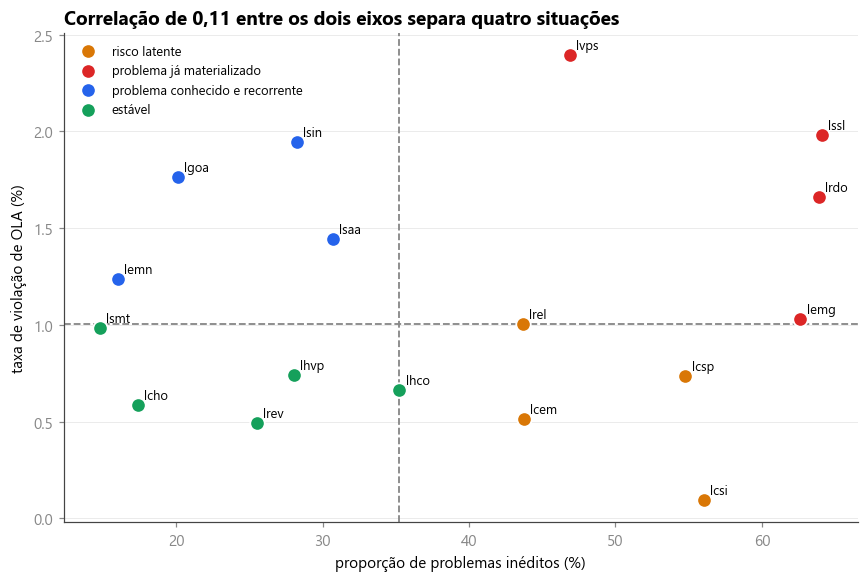

In [11]:
# figura 02: os quadrantes
fig, ax = plt.subplots(figsize=(8.0, 5.4))
mapa = {'risco latente': COR['ambar'], 'problema já materializado': COR['danger'],
        'problema conhecido e recorrente': COR['accent'], 'estável': COR['verde']}
for q, cor in mapa.items():
    s = prod[prod['quadrante'] == q]
    if not len(s):
        continue
    ax.scatter(s['prop_inedito'] * 100, s['taxa_violacao'] * 100, s=90, color=cor,
               label=q, zorder=4, edgecolors='white', linewidths=1.2)
    for i in s.index:
        ax.annotate(i, xy=(s.loc[i, 'prop_inedito'] * 100, s.loc[i, 'taxa_violacao'] * 100),
                    xytext=(4, 4), textcoords='offset points', fontsize=8.5)
ax.axvline(mediana_ined * 100, color=COR['cinza'], lw=1.2, ls='--')
ax.axhline(mediana_taxa * 100, color=COR['cinza'], lw=1.2, ls='--')
ax.set_xlabel('proporção de problemas inéditos (%)')
ax.set_ylabel('taxa de violação de OLA (%)')
ax.set_title('Correlação de 0,11 entre os dois eixos separa quatro situações', loc='left')
ax.legend(loc='upper left', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '02_quadrantes'); plt.show()

**Como ler o gráfico.** O eixo horizontal mede quanto do que acontece no produto é problema novo. O
eixo vertical mede quanto de fato violou o OLA. As duas linhas tracejadas são as medianas do conjunto, e
dividem os produtos em quatro situações:

| Situação | Problema novo | Violação | Leitura |
|---|---|---|---|
| **problema já materializado** | acima da mediana | acima | o produto recebe casos novos e já está violando |
| **risco latente** | acima da mediana | abaixo | recebe casos novos e ainda não violou |
| **problema conhecido e recorrente** | abaixo | acima | viola, mas sempre pelo mesmo motivo |
| **estável** | abaixo | abaixo | sem sinal de deterioração |

**Achado:** a divisão só produz quatro grupos porque os dois eixos são independentes, com correlação de
0,11 conforme medido na seção 3. Se fossem correlacionados, os produtos se alinhariam na diagonal e
haveria apenas uma dimensão de variação, não quatro situações distintas.

O quadrante de **risco latente** é o que justifica a existência deste notebook. Ele reúne produtos que
concentram problema novo acima da mediana e ainda registram violação abaixo dela. Como o
`05_causas_recorrentes.ipynb` mediu que o problema inédito viola o OLA 4,6 vezes mais que o de rotina,
esses produtos acumulam a característica associada à violação sem que ela tenha se materializado no
período observado.

Nenhum deles seria sinalizado pelo modelo de risco, porque a avaliação é por incidente e cada caso
desses produtos recebe probabilidade individual baixa. O padrão existe apenas no agregado do produto.

O quadrante de **problema conhecido e recorrente** exige leitura oposta: o produto viola, mas o faz por
motivo repetido. É a situação em que padronizar a resposta tende a resolver, ao contrário do risco
latente, em que o problema ainda não é conhecido o suficiente para ser padronizado.

### 4.6 Sensibilidade da nota aos pesos

O peso igual entre componentes é escolha sem lastro no dado, portanto é necessário medir o quanto o
resultado depende dela. O teste recalcula a nota dobrando o peso de um componente por vez e mede a
alteração no ranking.

In [12]:
from itertools import combinations

def concordancia(a, b):
    """Proporção de pares de produtos que mantêm a ordem relativa entre dois rankings."""
    itens = list(a.index)
    iguais = sum(1 for x, y in combinations(itens, 2)
                 if (a[x] - a[y]) * (b[x] - b[y]) > 0)
    return iguais / len(list(combinations(itens, 2)))

base_nota = prod['nota']
linhas = []
for comp in USADOS:
    pesos = {c: (2.0 if c == comp else 1.0) for c in USADOS}
    nota_alt, _ = calcula_nota(prod, USADOS, pesos)
    linhas.append({'peso dobrado em': comp,
                   'concordância do ranking %': round(concordancia(base_nota, nota_alt) * 100, 1),
                   'variação máxima da nota': round((nota_alt - base_nota).abs().max(), 1),
                   'muda o pior colocado': ranking.index[0] != nota_alt.idxmin()})
print(pd.DataFrame(linhas).to_string(index=False))
print()
# so a taxa de violacao, para comparar com o que o modelo de risco entregaria
so_taxa = (100 * (1 - prod['taxa_violacao'].rank(pct=True))).round(1)
print(f'concordância entre a nota composta e um ranking feito só pela taxa de violação: '
      f'{fmt(concordancia(base_nota, so_taxa)*100, 1)}%')

  peso dobrado em  concordância do ranking %  variação máxima da nota  muda o pior colocado
    taxa_violacao                       91.2                      8.4                 False
     prop_inedito                       94.1                      5.7                 False
   prop_sem_causa                       90.4                      7.2                 False
duracao_mediana_h                       92.6                      9.0                 False
        tendencia                       91.9                      7.1                 False

concordância entre a nota composta e um ranking feito só pela taxa de violação: 70,6%


**Achado:** dobrar o peso de qualquer componente preserva a maior parte da ordem entre produtos, o
que indica que o ranking não é artefato da escolha de pesos iguais. A variação máxima de nota fica em
poucos pontos.

O segundo número é o mais relevante para a justificativa deste notebook: a concordância entre a nota
composta e um ranking construído apenas com a taxa de violação, que é a informação que o modelo de
risco fornece. Uma concordância baixa significa que a nota ordena os produtos de forma substancialmente
diferente, e portanto carrega informação que o modelo de risco não expressa.

### 4.7 Saída para a aplicação

Tabela por produto com nota, posição, quadrante e os componentes em valor bruto e em posição relativa,
para que a interface exiba a decomposição junto da nota.

In [13]:
saida = prod.copy()
for comp in USADOS:
    saida[f'pos_{comp}'] = POSICOES[comp].round(3)
colunas = (['posicao', 'nota', 'quadrante', 'incidentes', 'violacoes'] + USADOS
           + [f'pos_{c}' for c in USADOS])
saida = saida[colunas].sort_values('posicao')
destino = RAIZ / 'data' / 'interim' / '07_saude_produto.parquet'
saida.to_parquet(destino)
print(f'{destino.name}: {len(saida)} linhas × {saida.shape[1]} colunas')
print()
print(saida.head(5).round(3).to_string())

07_saude_produto.parquet: 17 linhas × 15 colunas

         posicao  nota                        quadrante  incidentes  violacoes  taxa_violacao  prop_inedito  prop_sem_causa  duracao_mediana_h  tendencia  pos_taxa_violacao  pos_prop_inedito  pos_prop_sem_causa  pos_duracao_mediana_h  pos_tendencia
Produto                                                                                                                                                                                                                                                 
lcho           1  70.6                          estável         511          3          0.006         0.174           0.108              0.946     -0.002              0.235             0.176               0.529                  0.176          0.353
lcem           2  69.4                    risco latente        3496         18          0.005         0.438           0.058              0.725     -0.001              0.176             0.647             

## 5. Conclusões e limitações

### Principais achados

1. **O score não é redundante com o modelo de risco.** A correlação entre taxa de violação e proporção
   de problemas inéditos é de 0,11, e a concordância entre a nota composta e um ranking feito apenas
   pela taxa de violação é parcial. A nota ordena os produtos de forma diferente.
2. **Os dois artefatos são complementares por causa da restrição de vazamento.** O modelo de risco só
   pode usar informação disponível na abertura; o score descreve o passado e por isso pode usar código
   de fechamento e duração, campos que o modelo é obrigado a excluir.
3. **Existe um quadrante de risco latente**: produtos com concentração alta de problemas inéditos e taxa
   de violação ainda baixa. Como o problema inédito viola o OLA 4,6 vezes mais, essa combinação
   representa exposição não materializada, e é invisível a uma avaliação por incidente.
4. **Dois componentes eram redundantes.** Duração mediana e incidentes por ativo apresentam correlação
   de 0,85; o segundo foi descartado.
5. **O ranking é estável quanto aos pesos.** Dobrar o peso de qualquer componente preserva a maior
   parte da ordem entre produtos.

### Decisões registradas

- **Nota por posição relativa**, não por valor absoluto, porque não existe valor de referência por
  componente no material oficial. A nota compara produtos entre si.
- **Peso igual entre os cinco componentes**, por ausência de base no dado para diferenciá-los, com a
  sensibilidade medida na seção 4.6.
- **Volume mínimo de 200 incidentes** para entrar no ranking, porque taxa calculada sobre poucos casos
  não é interpretável.
- **A interface exibe nota e decomposição juntas.** Nota isolada não é acionável.

### Limitações declaradas

1. **Poucos produtos no conjunto.** Apenas os que superam o volume mínimo entram, e o ranking é
   relativo a esse conjunto. Um produto com nota alta é o melhor entre os avaliados, não um produto sem
   problemas.
2. **A nota é relativa e não comparável entre execuções** com conjuntos diferentes de produtos.
3. **A tendência é medida entre dois semestres de um único ano**, o que a torna sensível a eventos
   isolados, como a mudança de processo de setembro de 2025 documentada no `01_eda.ipynb`.
4. **O quadrante de risco latente é hipótese fundamentada, não previsão validada.** Ele se apoia no
   gradiente de familiaridade do `05_causas_recorrentes.ipynb`, mas não foi verificado que os produtos
   desse quadrante de fato passam a violar mais no período seguinte. A verificação exigiria mais de um
   ano de dado.
5. **Dois componentes usam campos preenchidos no fechamento**, código de fechamento e duração. É
   adequado para diagnóstico e impede que a nota seja usada como previsão.
6. **O componente de duração é distorcido por encerramento automático.** No produto `lcsi` a duração
   mediana de 335 horas reflete inatividade e não atendimento lento, conforme a seção 4.5. Os
   incidentes de encerramento automático não foram excluídos porque o dataset não permite decidir se
   representam trabalho da operação.